In [4]:
import pandas as pd
import sqlite3

In [5]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
# Convert Date Columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [7]:
# Standardize Column Names
df.columns = [
    "row_id",
    "order_id",
    "order_date",
    "ship_date",
    "ship_mode",
    "customer_id",
    "customer_name",
    "segment",
    "country",
    "city",
    "state",
    "postal_code",
    "region",
    "product_id",
    "category",
    "sub_category",
    "product_name",
    "sales",
    "quantity",
    "discount",
    "profit"
]

In [8]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [9]:
# SQLite Database Setup
conn = sqlite3.connect("superstore.db")


The prepared pandas DataFrame is inserted into the SQLite `orders` table.

The data is appended to the newly created table without adding the pandas DataFrame index as a database column.

In [10]:
conn.execute("DROP TABLE IF EXISTS orders")

conn.execute("""
CREATE TABLE orders (
    row_id INTEGER,
    order_id TEXT,
    order_date DATE,
    ship_date DATE,
    ship_mode TEXT,
    customer_id TEXT,
    customer_name TEXT,
    segment TEXT,
    country TEXT,
    city TEXT,
    state TEXT,
    postal_code INTEGER,
    region TEXT,
    product_id TEXT,
    category TEXT,
    sub_category TEXT,
    product_name TEXT,
    sales NUMERIC,
    quantity INTEGER,
    discount NUMERIC,
    profit NUMERIC
)
""")

conn.commit()

In [11]:
#Finding out if it worked
df.to_sql(
    "orders",
    conn,
    if_exists="append",
    index=False
)

9994

In [12]:
conn.commit()

In [13]:
pd.read_sql("""
SELECT COUNT(*) AS row_count
FROM orders;
""", conn)

,row_count
0,9994


In [14]:
#Verifying date values
pd.read_sql("""
SELECT order_date, ship_date
FROM orders
LIMIT 10;
""", conn)

,order_date,ship_date
0,2016-11-08 00:00:00,2016-11-11 00:00:00
1,2016-11-08 00:00:00,2016-11-11 00:00:00
2,2016-06-12 00:00:00,2016-06-16 00:00:00
3,2015-10-11 00:00:00,2015-10-18 00:00:00
4,2015-10-11 00:00:00,2015-10-18 00:00:00
5,2014-06-09 00:00:00,2014-06-14 00:00:00
6,2014-06-09 00:00:00,2014-06-14 00:00:00
7,2014-06-09 00:00:00,2014-06-14 00:00:00
8,2014-06-09 00:00:00,2014-06-14 00:00:00
9,2014-06-09 00:00:00,2014-06-14 00:00:00


In [15]:
pd.read_sql("""
SELECT*
FROM orders;
""", conn)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16 00:00:00,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21 00:00:00,2014-01-23 00:00:00,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26 00:00:00,2017-03-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26 00:00:00,2017-03-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26 00:00:00,2017-03-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


## Q1 - Dataset Profile
The first query provides a high-level profile of the dataset.

It calculates:

- Total number of records
- Number of distinct customers
- Number of distinct products
- Earliest order date
- Latest order date

In [16]:
q1 = """
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT customer_id) AS distinct_customers,
    COUNT(DISTINCT product_id) AS distinct_products,
    MIN(order_date) AS min_order_date, 
    MAX(order_date) AS max_order_date
FROM orders;
"""

pd.read_sql(q1,conn)

,row_count,distinct_customers,distinct_products,min_order_date,max_order_date
0,9994,793,1862,2014-01-03 00:00:00,2017-12-30 00:00:00


### Finding

The dataset contains **9,994 order-line records**, **793 distinct customers**, and **1,862 distinct products**.

The analysis covers the period from **January 3, 2014 to December 30, 2017**.

## Q2 — NULL Value Check

This query checks every column for NULL values.

A `CASE WHEN` expression returns `1` when a value is NULL and `0` otherwise. Summing these values produces the total number of NULL records for each column.


In [17]:
q2 = """
SELECT
    SUM(CASE WHEN row_id IS NULL THEN 1 ELSE 0 END) AS row_id_nulls,
    SUM(CASE WHEN order_id IS NULL THEN 1 ELSE 0 END) AS order_id_nulls,
    SUM(CASE WHEN order_date IS NULL THEN 1 ELSE 0 END) AS order_date_nulls,
    SUM(CASE WHEN ship_date IS NULL THEN 1 ELSE 0 END) AS ship_date_nulls,
    SUM(CASE WHEN ship_mode IS NULL THEN 1 ELSE 0 END) AS ship_mode_nulls,
    SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) AS customer_id_nulls,
    SUM(CASE WHEN customer_name IS NULL THEN 1 ELSE 0 END) AS customer_name_nulls,
    SUM(CASE WHEN segment IS NULL THEN 1 ELSE 0 END) AS segment_nulls,
    SUM(CASE WHEN country IS NULL THEN 1 ELSE 0 END) AS country_nulls,
    SUM(CASE WHEN city IS NULL THEN 1 ELSE 0 END) AS city_nulls,
    SUM(CASE WHEN state IS NULL THEN 1 ELSE 0 END) AS state_nulls,
    SUM(CASE WHEN postal_code IS NULL THEN 1 ELSE 0 END) AS postal_code_nulls,
    SUM(CASE WHEN region IS NULL THEN 1 ELSE 0 END) AS region_nulls,
    SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) AS product_id_nulls,
    SUM(CASE WHEN category IS NULL THEN 1 ELSE 0 END) AS category_nulls,
    SUM(CASE WHEN sub_category IS NULL THEN 1 ELSE 0 END) AS sub_category_nulls,
    SUM(CASE WHEN product_name IS NULL THEN 1 ELSE 0 END) AS product_name_nulls,
    SUM(CASE WHEN sales IS NULL THEN 1 ELSE 0 END) AS sales_nulls,
    SUM(CASE WHEN quantity IS NULL THEN 1 ELSE 0 END) AS quantity_nulls,
    SUM(CASE WHEN discount IS NULL THEN 1 ELSE 0 END) AS discount_nulls,
    SUM(CASE WHEN profit IS NULL THEN 1 ELSE 0 END) AS profit_nulls
FROM orders;
"""

pd.read_sql(q2, conn)

,row_id_nulls,order_id_nulls,order_date_nulls,ship_date_nulls,ship_mode_nulls,customer_id_nulls,customer_name_nulls,segment_nulls,country_nulls,city_nulls,...,postal_code_nulls,region_nulls,product_id_nulls,category_nulls,sub_category_nulls,product_name_nulls,sales_nulls,quantity_nulls,discount_nulls,profit_nulls
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Finding

All 21 columns contain **0 NULL values**.

Therefore, no missing values were identified in the loaded dataset.

## Q3 — Duplicate Order-Line Detection

This query checks for potential duplicate order lines using the combination of `order_id` and `product_id`.


In [18]:
q3 = """SELECT order_id, product_id, COUNT(*) AS duplicate_count FROM orders GROUP BY order_id, product_id HAVING COUNT(*) > 1;"""
pd.read_sql(q3, conn)

,order_id,product_id,duplicate_count
0,CA-2015-103135,OFF-BI-10000069,2
1,CA-2016-129714,OFF-PA-10001970,2
2,CA-2016-137043,FUR-FU-10003664,2
3,CA-2016-140571,OFF-PA-10001954,2
4,CA-2017-118017,TEC-AC-10002006,2
5,CA-2017-152912,OFF-ST-10003208,2
6,US-2014-150119,FUR-CH-10002965,2
7,US-2016-123750,TEC-AC-10004659,2


### Finding

The query identified **8 Order ID + Product ID combinations**, with each combination appearing twice.

## Q4 — Average Shipping Time by Ship Mode

This query calculates the average number of days between the order date and ship date for each shipping mode.


In [19]:
q4 = """SELECT ship_mode, AVG(julianday(ship_date) - julianday(order_date)) AS avg_days_to_ship FROM orders GROUP BY ship_mode ORDER BY avg_days_to_ship;"""

pd.read_sql(q4, conn)

,ship_mode,avg_days_to_ship
0,Same Day,0.044199
1,First Class,2.182705
2,Second Class,3.238046
3,Standard Class,5.006535


### Finding

Average shipping time varies across shipping modes.

Standard Class has the highest average shipping time at approximately **5.01 days**, while Same Day orders average approximately **0.04 days**.

## Q5 — Profitability by Region, Category, and Sub-Category

This query evaluates sales and profitability across three business dimensions:

- Region
- Category
- Sub-Category

For each combination, total sales, total profit, and profit margin are calculated.


In [18]:
q5 = """ SELECT region, category, sub_category, 
    SUM(sales) AS total_sales, 
    SUM(profit) AS total_profit, 
    SUM(profit) / NULLIF(SUM(sales), 0) AS profit_margin  
    FROM orders GROUP BY region, category, sub_category ORDER BY total_profit ASC;"""

pd.read_sql(q5, conn)

,region,category,sub_category,total_sales,total_profit,profit_margin
0,East,Furniture,Tables,39139.807,-11025.3801,-0.281692
1,South,Furniture,Tables,43916.192,-4623.0579,-0.105270
2,Central,Furniture,Furnishings,15254.370,-3906.2168,-0.256072
3,Central,Furniture,Tables,39154.971,-3559.6504,-0.090912
4,Central,Office Supplies,Appliances,23582.033,-2638.6175,-0.111891
...,...,...,...,...,...,...
63,Central,Technology,Copiers,37259.570,15608.8413,0.418922
64,West,Office Supplies,Binders,55961.113,16096.8016,0.287643
65,West,Technology,Accessories,61114.116,16484.5983,0.269735
66,East,Technology,Copiers,53219.462,17022.8418,0.319861


### Finding

Profitability varies substantially across regions and product sub-categories.

For example, East Furniture Tables generated **USD -11,025.38** in profit, while West Technology Copiers generated **USD 19,327.24**.

## Q6 — Top 5 and Bottom 5 Sub-Categories by Profit

This query identifies the five sub-categories with the highest and lowest total profit.

In [19]:
q6 = """SELECT * FROM (
    SELECT sub_category, SUM(profit) AS total_profit, 'Top 5' AS ranking_group
    FROM orders
    GROUP BY sub_category
    ORDER BY total_profit DESC
    LIMIT 5
)

UNION ALL

SELECT * FROM (
    SELECT sub_category, SUM(profit) AS total_profit, 'Bottom 5' AS ranking_group
    FROM orders
    GROUP BY sub_category
    ORDER BY total_profit ASC
    LIMIT 5
);"""

pd.read_sql(q6, conn)

,sub_category,total_profit,ranking_group
0,Copiers,55617.8249,Top 5
1,Phones,44515.7306,Top 5
2,Accessories,41936.6357,Top 5
3,Paper,34053.5693,Top 5
4,Binders,30221.7633,Top 5
5,Tables,-17725.4811,Bottom 5
6,Bookcases,-3472.5560,Bottom 5
7,Supplies,-1189.0995,Bottom 5
8,Fasteners,949.5182,Bottom 5
9,Machines,3384.7569,Bottom 5


### Finding

Copiers generated the highest total profit at **$55,617.82**.

Tables had the lowest total profit at **-$17,725.48**.

The bottom five are based on total profit ranking; therefore, not every sub-category in the Bottom 5 has negative profit.

## Q7 — Profitability by Discount Band

This query groups transactions into four discount bands using `CASE WHEN`:

- 0%
- 1–20%
- 21–40%
- 41%+

For each band, the query calculates order count, average profit, and total profit.

In [20]:
q7 = """SELECT CASE
        WHEN discount = 0 THEN '0%'
        WHEN discount <= 0.20 THEN '1-20%'
        WHEN discount <= 0.40 THEN '21-40%'
        ELSE '41%+'
    END AS discount_band,

    COUNT(DISTINCT order_id) AS order_count,
    AVG(profit) AS avg_profit,
    SUM(profit) AS total_profit
FROM orders

GROUP BY
    CASE
        WHEN discount = 0 THEN '0%'
        WHEN discount <= 0.20 THEN '1-20%'
        WHEN discount <= 0.40 THEN '21-40%'
        ELSE '41%+'
    END;
"""

pd.read_sql(q7, conn)

,discount_band,order_count,avg_profit,total_profit
0,0%,2644,66.900292,320987.6032
1,1-20%,2507,26.501571,100785.4745
2,21-40%,400,-77.864055,-35817.4655
3,41%+,737,-106.708028,-99558.5905


### Finding

Profitability decreases across the higher discount bands in this dataset.

The 0% discount band generated **USD 320,987.60** in total profit, while the 41%+ discount band generated **USD -99,558.59**.

The 21–40% and 41%+ bands both had negative average profit.

This is a descriptive relationship and does not prove that higher discounts alone caused the lower profitability.

## Q8 — Year-over-Year Sales Analysis

This query calculates total sales by year and uses the `LAG()` window function to compare each year's sales with the previous year.


In [21]:
q8 = """
SELECT
    year,
    total_sales,
    LAG(total_sales) OVER (ORDER BY year) AS previous_sales,
    total_sales - LAG(total_sales) OVER (ORDER BY year) AS yoy_change,
    100.0 * (total_sales - LAG(total_sales) OVER (ORDER BY year)) / LAG(total_sales) OVER (ORDER BY year) AS yoy_percent
FROM (SELECT strftime('%Y', order_date) AS year, SUM(sales) AS total_sales FROM orders GROUP BY strftime('%Y', order_date))
ORDER BY year;
"""

pd.read_sql(q8, conn)

,year,total_sales,previous_sales,yoy_change,yoy_percent
0,2014,484247.4981,NaN,NaN,NaN
1,2015,470532.5090,484247.4981,-13714.9891,-2.832227
2,2016,609205.5980,470532.5090,138673.0890,29.471521
3,2017,733215.2552,609205.5980,124009.6572,20.355962


### Finding

Sales decreased by **2.83% in 2015**.

Sales then increased by **29.47% in 2016** and **20.36% in 2017**, reaching **USD 733,215.26** in 2017.

## Q9 — Negative-Profit Sub-Categories

This query identifies sub-categories with negative total profit and calculates their share of total sales revenue.


In [22]:
q9 = """
SELECT
    sub_category,
    SUM(profit) AS total_profit,
    SUM(sales) AS total_sales,
    100.0 * SUM(sales) / (SELECT SUM(sales) FROM orders) AS revenue_share_percent
FROM orders
GROUP BY sub_category
HAVING SUM(profit) < 0
ORDER BY total_profit ASC;
"""

pd.read_sql(q9, conn)

,sub_category,total_profit,total_sales,revenue_share_percent
0,Tables,-17725.4811,206965.5320,9.009466
1,Bookcases,-3472.5560,114879.9963,5.000869
2,Supplies,-1189.0995,46673.5380,2.031757


### Finding

Three sub-categories generated negative total profit:

- Tables: **USD -17,725.48**
- Bookcases: **USD -3,472.56**
- Supplies: **USD -1,189.10**


## Q10 — Top Customers by Lifetime Profit

This query ranks customers according to their total lifetime profit.

For each customer, it calculates:

- Lifetime profit
- Number of orders
- Average order value


In [23]:
q10 = """
SELECT
    customer_id,
    customer_name,
    SUM(profit) AS lifetime_profit,
    COUNT(DISTINCT order_id) AS order_count,
    SUM(sales) / COUNT(DISTINCT order_id) AS average_order_value
FROM orders
GROUP BY customer_id, customer_name
ORDER BY lifetime_profit DESC
LIMIT 10;
"""

pd.read_sql(q10, conn)

,customer_id,customer_name,lifetime_profit,order_count,average_order_value
0,TC-20980,Tamara Chand,8981.3239,5,3810.443600
1,RB-19360,Raymond Buch,6976.0959,6,2519.556500
2,SC-20095,Sanjit Chand,5757.4119,9,1571.370444
3,HL-15040,Hunter Lopez,5622.4292,6,2145.549667
4,AB-10105,Adrian Barton,5444.8055,10,1447.357100
5,TA-21385,Tom Ashbrook,4703.7883,4,3648.905000
6,CM-12385,Christopher Martinez,3899.8904,4,2238.505000
7,KD-16495,Keith Dawkins,3038.6254,12,681.771333
8,AR-10540,Andy Reiter,2884.6208,6,1101.408000
9,DR-12940,Daniel Raglin,2869.0760,8,1043.858500


### Finding

The highest lifetime-profit customer in the analysis was Tamara Chand, with **USD 8,981.32** in lifetime profit across **5 orders**.

The average order value was **USD 3,810.44**.

# Visualizations

The following visualizations were created from SQL query results using Python and Matplotlib.

The visualizations focus on three important aspects of the analysis:

1. Profitability by sub-category
2. Average profit by discount band
3. Yearly sales trend

In [25]:
q_plot1 = """
SELECT sub_category, SUM(profit) AS total_profit FROM orders
GROUP BY sub_category
ORDER BY total_profit;
"""

profit_by_subcategory = pd.read_sql(q_plot1, conn)

profit_by_subcategory

,sub_category,total_profit
0,Tables,-17725.4811
1,Bookcases,-3472.5560
2,Supplies,-1189.0995
3,Fasteners,949.5182
4,Machines,3384.7569
5,Labels,5546.2540
6,Art,6527.7870
7,Envelopes,6964.1767
8,Furnishings,13059.1436
9,Appliances,18138.0054


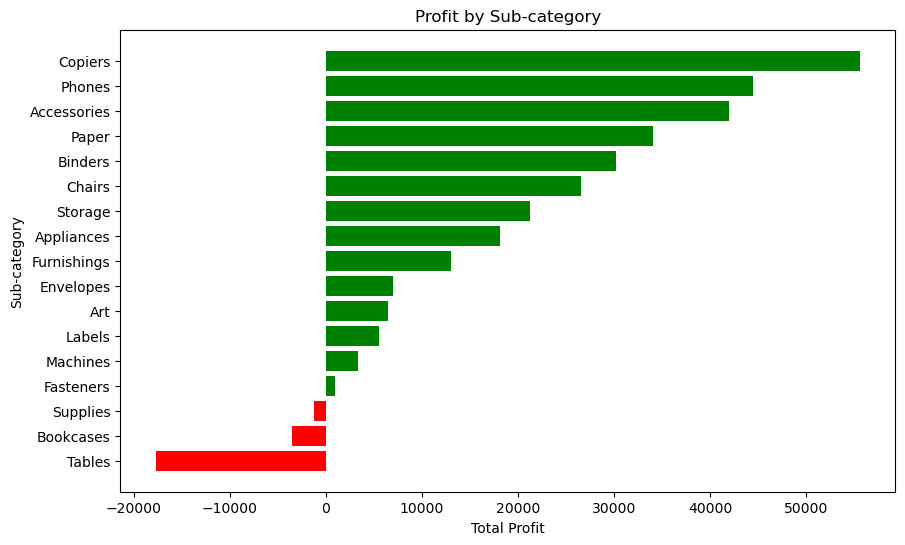

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = [ 'red' if profit < 0 else 'green' for profit in profit_by_subcategory['total_profit'] ]
plt.barh( profit_by_subcategory['sub_category'], profit_by_subcategory['total_profit'], color=colors)
plt.xlabel('Total Profit')
plt.ylabel('Sub-category')
plt.title('Profit by Sub-category')
plt.savefig('profit_by_subcategory.png', dpi=300)
plt.show()



The visualization shows substantial differences in profitability across sub-categories.

Copiers is the strongest contributor by total profit, while Tables has the largest negative profit.

In [27]:
q_plot2 = """
SELECT 
    CASE 
        WHEN discount = 0 THEN '0%'
        WHEN discount <= 0.20 THEN '1-20%'
        WHEN discount <= 0.40 THEN '21-40%'
        ELSE '41%+'
    END AS discount_band,
    AVG(profit) AS avg_profit
FROM orders
GROUP BY discount_band;
"""

profit_by_discount = pd.read_sql(q_plot2, conn)
profit_by_discount

,discount_band,avg_profit
0,0%,66.900292
1,1-20%,26.501571
2,21-40%,-77.864055
3,41%+,-106.708028


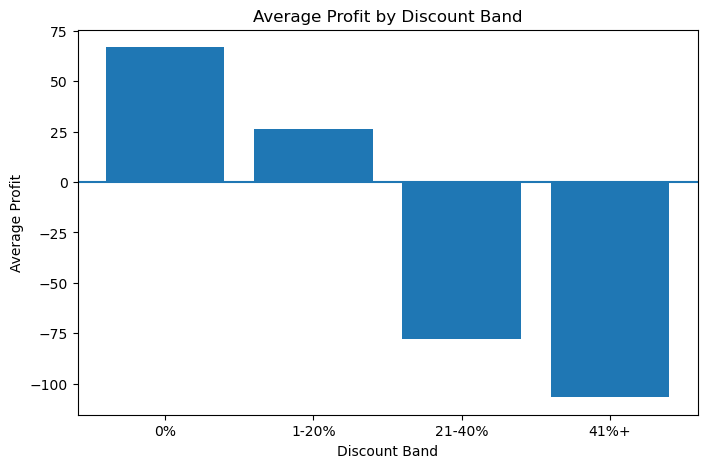

In [28]:
plt.figure(figsize=(8, 5))

plt.bar( profit_by_discount['discount_band'], profit_by_discount['avg_profit'] )
plt.xlabel('Discount Band')
plt.ylabel('Average Profit')
plt.title('Average Profit by Discount Band')
plt.axhline(0)
plt.savefig('average_profit_by_discount_band.png', dpi=300)

plt.show()


Average profit decreases as the discount band increases in the analyzed dataset.

The 21–40% and 41%+ bands show negative average profit.

In [29]:
sales_by_year = pd.read_sql(q8, conn)
sales_by_year

,year,total_sales,previous_sales,yoy_change,yoy_percent
0,2014,484247.4981,NaN,NaN,NaN
1,2015,470532.5090,484247.4981,-13714.9891,-2.832227
2,2016,609205.5980,470532.5090,138673.0890,29.471521
3,2017,733215.2552,609205.5980,124009.6572,20.355962


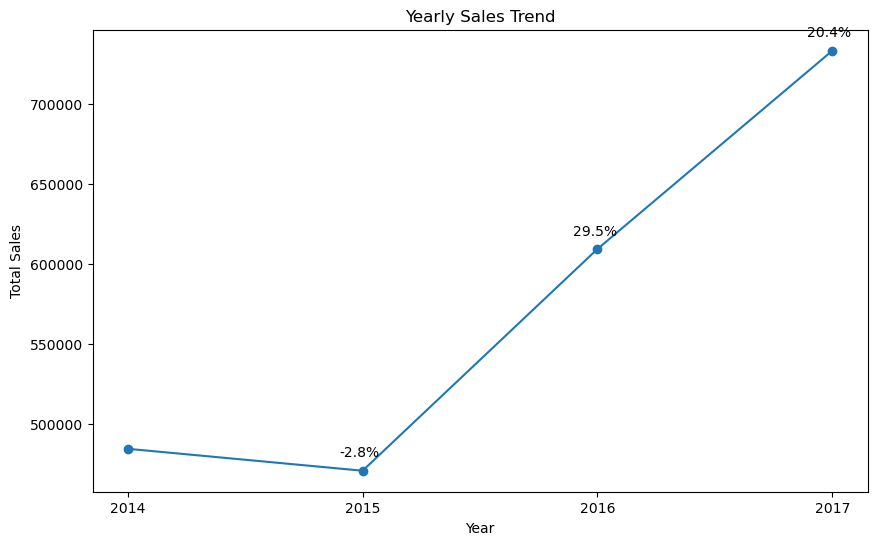

In [35]:
plt.figure(figsize=(10, 6))

plt.plot( sales_by_year['year'], sales_by_year['total_sales'], marker='o' )
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Yearly Sales Trend')

# YoY faizlərinin qrafiki
for i, row in sales_by_year.iterrows():
    if pd.notna(row['yoy_percent']):
        plt.annotate(
            f"{row['yoy_percent']:.1f}%",
            (row['year'], row['total_sales']),
            textcoords="offset points",
            xytext=(-2, 10),
            ha='center'
        )

plt.savefig('yearly_sales_trend.png', dpi=300)

plt.show()


Sales declined slightly in 2015 and then increased substantially in 2016 and 2017.

The highest annual sales were recorded in 2017 at **$733,215.26**.

# Business Insights

## 1. Review High-Discount Transactions

The analysis shows that higher discount levels are associated with lower profitability in the dataset.

The **21–40%** discount band generated **USD -35,817.47** in total profit, while the **41%+** discount band generated **USD -99,558.59**. The average profit was also negative in both groups, at **USD -77.86** and **-$106.71**, respectively.

This shows that high discount levels may have a negative effect on profitability. It would be useful to analyze these transactions by product, region, and customer segment to understand where the negative profit is coming from.


## 2. Investigate Loss-Making Sub-Categories

The analysis shows that **Tables, Bookcases, and Supplies** generated negative total profit.

- Tables: **USD -17,725.48**
- Bookcases: **USD -3,472.56**
- Supplies: **USD -1,189.10**

At the same time, these three sub-categories represent approximately **16.04% of total revenue**.

This is important because these products generate a considerable amount of revenue but still result in an overall loss. It would be useful to look at their individual products, regions, and discount levels to better understand the reasons for these losses.


## 3. Monitor Strong Profit Contributors

Some sub-categories contribute much more to total profit than others.

**Copiers** generated the highest total profit at **USD 55,617.82**, followed by **Phones** at **USD 44,515.73** and **Accessories** at **USD 41,936.64**.

These results show that these sub-categories are important contributors to the overall profit in the dataset.

It would be useful to analyze their performance across different regions and customer segments to see where they generate the highest profit.


## 4. Investigate Sales Growth After 2015

The yearly sales analysis shows that sales decreased by **2.83% in 2015**.

After that, sales increased by **29.47% in 2016** and **20.36% in 2017**. Total sales reached **USD 733,215.26 in 2017**.

This shows that the business experienced strong sales growth after 2015. It would be useful to analyze the sales growth by region, category, and customer segment to understand which areas contributed most to this increase.

It is also important to compare sales growth with profit and profit margin to see whether the increase in sales was also accompanied by improved profitability.